在 DQN 之后，学术界涌现出了非常多的改进算法。本章将介绍其中两个非常著名的算法：Double DQN 和 Dueling DQN，这两个算法的实现非常简单，只需要在 DQN 的基础上稍加修改，它们能在一定程度上改善 DQN 的效果。如果读者想要了解更多、更详细的 DQN 改进方法，可以阅读 Rainbow 模型的论文及其引用文献。

Double DQN

普通的 DQN 算法通常会导致对 Q 值的过高估计，详细理论看飞书

本节采用的环境是倒立摆（Inverted Pendulum），该环境下有一个处于随机位置的倒立摆环境的状态包括倒立摆角度的正弦值，余弦值，角速度，动作为对倒立摆施加的力矩，每一步都会根据当前倒立摆的状态的好坏给予智能体不同的奖励，该环境的奖励函数为 $-(θ^2+0.1{\dot{θ}}^2+0.001a^2)$;倒立摆向上保持直立不动时奖励为 0，倒立摆在其他位置时奖励为负数。环境本身没有终止状态，运行 200 步后游戏自动结束。

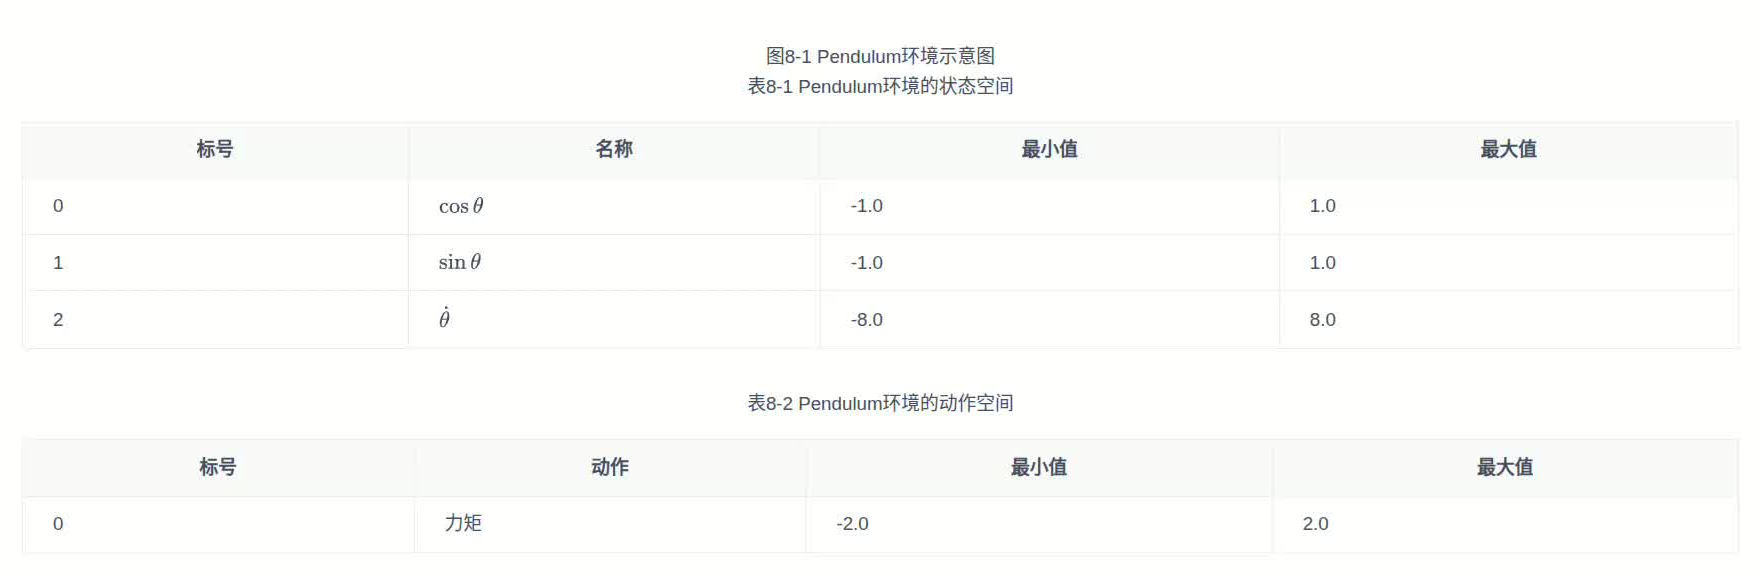

由于 DQN 只能处理离散动作环境,因此我们无法直接用 DQN 来处理倒立摆环境，但倒立摆环境可以比较方便地验证 DQN 对 Q 值的过高估计：倒立摆环境下 Q 值的最大估计应为 0（倒立摆向上保持直立时能选取的最大 Q 值）;Q 值出现大于 0 的情况则说明出现了过高估计,为了能够应用 DQN，我们采用离散化动作的技巧。例如，下面的代码将连续的动作空间离散为 11 个动作。动作[0,1,2,...,9,10]分别代表力矩[-2,-1.6,-1.2,...,1.2,1.6,2]

In [2]:
import random
import gym
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rl_utils
from tqdm import tqdm


class Qnet(torch.nn.Module):
    """ 
        只有一层隐藏层的Q网络 
    """
    def __init__(self, state_dim, hidden_dim, action_dim):
        """
            初始化
            state_dim：输入层维度
            hidden_dim：隐藏层维度
            action_dim：输出层维度
        """
        super(Qnet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        """
            前向传播
            x：输入特征
            前向传播在我们创建网络实例的时候会自动调用，然后我们调用网络实例的时候会自动返回输出层的值
        """
        x = F.relu(self.fc1(x))
        return self.fc2(x)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


接下来我们在 DQN 代码的基础上稍做修改以实现 Double DQN。

In [3]:
class DQN:
    """
        DQN算法,包括Double DQN
    """
    def __init__(self, state_dim, hidden_dim, action_dim, learning_rate, gamma, epsilon, target_update, device, dqn_type='VanillaDQN'):
        """
            初始化
            state_dim：输入层维度（状态空间的维度）
            hidden_dim：隐藏层维度
            action_dim：输出层维度
            learning_rate：学习率
            gamma：折扣因子
            epsilon：epsilon-贪婪策略中的探索概率
            target_update：目标网络更新的频率（经过多少步更新一次）
            device：计算运行的设备
            dqn_type：算法类型，默认是普通DQN
        """
        self.action_dim = action_dim
        
        # 1. 实例化主网络 (Q-Network)。用于选择动作和不断被训练更新（训练网络）
        self.q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)
        
        # 2. 实例化目标网络 (Target Q-Network)
        # 它的结构和主网络完全一样，但它的参数更新是滞后的。
        # 引入目标网络是为了打破数据间的相关性，让训练过程更加稳定。
        self.target_q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)
        
        # 3. 初始化优化器，这里使用 Adam 优化器，只优化主网络 q_net 的参数。
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=learning_rate)
        
        # 记录传入的各项超参数
        self.gamma = gamma
        self.epsilon = epsilon
        self.target_update = target_update
        
        # count 用于记录更新了多少次，以决定何时同步目标网络的参数
        self.count = 0
        self.dqn_type = dqn_type
        self.device = device


    def take_action(self, state):
        """
            epsilon-贪婪策略采取动作
            state：
        """
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else:
            state = torch.tensor([state], dtype=torch.float).to(self.device)
            action = self.q_net(state).argmax().item()
        return action
    
    def max_q_value(self, state):
        """
            计算最大 Q 值
            state
            用于在训练过程中评估当前状态的价值
        """
        # 同样将状态转为 Tensor 并传入设备
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        # 输入主网络得到所有动作的 Q 值，取最大值，并转换为 Python 数值返回
        return self.q_net(state).max().item()
    
    def update(self, transition_dict):
        """
            策略更新
            transition_dict：从经验回放池取出的一个批次（Batch）的数据字典
        """
        # transition_dict 是一个字典，里面包含了一个 Batch 的经验数据
        # 下面几行将 numpy 数组转换为 GPU/CPU 上的 Tensor 类型
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)

        # 注意这里的 .view(-1, 1)，它将一维数组变成列向量 (变成 [batch_size, 1] 的形状)
        # 这样做是为了后续的 gather 操作对齐维度
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

        # 计算训练网络的 Q 值
        # self.q_net(states) 输出所有动作的 Q 值，形状为 [batch_size, action_dim]
        # .gather(1, actions) 表示在第 1 维度（动作维度）上，把实际执行过的 action 对应的那个 Q 值提取出来
        # 提取后的 q_values 就是我们在状态 S 下，采取了动作 A 的预测 Q(S, A)
        q_values = self.q_net(states).gather(1, actions)

        # 计算目标网络的 Q 值
        if self.dqn_type == 'DoubleDQN': 
            # 【Double DQN 的做法】
            # 为了防止传统 DQN 过度估计 Q 值，Double DQN 将“选择动作”和“评估动作”拆开：
            # 1. 用主网络 (q_net) 来选择在下一状态中能产生最大 Q 值的动作索引 (max_action)
            # max(1)[1] 表示取每一行的最大值对应的索引 (也就是动作)
            max_action = self.q_net(next_states).max(1)[1].view(-1, 1)
            
            # 2. 用目标网络 (target_q_net) 来评估这个 max_action 的 Q 值是多少
            max_next_q_values = self.target_q_net(next_states).gather(1, max_action)
            
        else: 
            # 【传统 Vanilla DQN 的做法】
            # 直接用目标网络 (target_q_net) 既选出最大动作，又算出它的 Q 值
            # max(1)[0] 表示直接取每一行的最大 Q 值本身
            max_next_q_values = self.target_q_net(next_states).max(1)[0].view(-1, 1)

        # 计算 TD Target 和 损失函数
        # 计算 TD (Time Difference) 目标值：Y = R + gamma * max_Q(S', a')
        # (1 - dones) 是个小技巧：如果 done=1 (回合结束)，意味着没有下一个状态了，
        # 此时 (1 - dones) = 0，那么未来的期望 Q 值 max_next_q_values 就不会被加进去，只看当前奖励 R。
        q_targets = rewards + self.gamma * max_next_q_values * (1 - dones)  
        
        # 计算当前预测值 q_values 和目标值 q_targets 之间的均方误差 (MSE Loss)
        dqn_loss = torch.mean(F.mse_loss(q_values, q_targets))

        # 反向传播更新
        # 1. 梯度清零：防止前一次迭代的梯度累积到当前
        self.optimizer.zero_grad()  
        
        # 2. 反向传播：根据损失函数计算网络中各参数的梯度
        dqn_loss.backward()  
        
        # 3. 参数更新：优化器根据计算出的梯度，更新主网络 (q_net) 的参数
        self.optimizer.step()

        # 目标网络的延迟同步
        # 如果更新次数 count 达到了设定的频率 target_update
        if self.count % self.target_update == 0:
            # 将主网络 (q_net) 当前的参数权重，原封不动地复制给目标网络 (target_q_net)
            self.target_q_net.load_state_dict(self.q_net.state_dict())  
            
        # 更新计数器加 1
        self.count += 1

设置相应的超参数，并实现将倒立摆环境中的连续动作转化为离散动作的函数

In [5]:
lr = 1e-2
num_episodes = 200
hidden_dim = 128
gamma = 0.98
epsilon = 0.01
target_update = 50
buffer_size = 5000
minimal_size = 1000
batch_size = 64
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'Pendulum-v1'
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
action_dim = 11  # 将连续动作分成11个离散动作


def dis_to_con(discrete_action, env, action_dim): 
    """
        连续动作转回离散的函数
        env：环境实例
        action_dim：
    """
    action_lowbound = env.action_space.low[0]  # 连续动作的最小值
    action_upbound = env.action_space.high[0]  # 连续动作的最大值

    return action_lowbound + (discrete_action /
                              (action_dim - 1)) * (action_upbound -
                                                   action_lowbound)

/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


将训练代码封装成一个函数，方便我们来对比两种 DQN 的区别

In [6]:
def train_DQN(agent, env, num_episodes, replay_buffer, minimal_size,
              batch_size):
    """
        DQN 训练函数
        agent：算法实例
        env：环境实例
        num_episodes：
        replay_buffer：
        minimal_size：
    """
    return_list = []
    max_q_value_list = []
    max_q_value = 0
    for i in range(10):
        with tqdm(total=int(num_episodes / 10),
                  desc='Iteration %d' % i) as pbar:
            for i_episode in range(int(num_episodes / 10)):
                episode_return = 0
                state = env.reset()
                done = False
                while not done:
                    action = agent.take_action(state)
                    max_q_value = agent.max_q_value(
                        state) * 0.005 + max_q_value * 0.995  # 平滑处理
                    max_q_value_list.append(max_q_value)  # 保存每个状态的最大Q值
                    action_continuous = dis_to_con(action, env,
                                                   agent.action_dim)
                    next_state, reward, done, _ = env.step([action_continuous])
                    replay_buffer.add(state, action, reward, next_state, done)
                    state = next_state
                    episode_return += reward
                    if replay_buffer.size() > minimal_size:
                        b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(
                            batch_size)
                        transition_dict = {
                            'states': b_s,
                            'actions': b_a,
                            'next_states': b_ns,
                            'rewards': b_r,
                            'dones': b_d
                        }
                        agent.update(transition_dict)
                return_list.append(episode_return)
                if (i_episode + 1) % 10 == 0:
                    pbar.set_postfix({
                        'episode':
                        '%d' % (num_episodes / 10 * i + i_episode + 1),
                        'return':
                        '%.3f' % np.mean(return_list[-10:])
                    })
                pbar.update(1)
    return return_list, max_q_value_list

先训练 DQN 并打印出其学习过程中最大 Q 值的情况

/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(
Iteration 0:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_5866/2443180206.py:50: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1724789116784/work/torch/csrc/utils/tensor_new.cpp:278.)
  state = torch.tensor([state], dtype=torch.float).to(self.device)
Iteration 9: 100%|██████████| 20/20 [00:06<00:00,  3.30it/s, episode=200, return=-261.196]


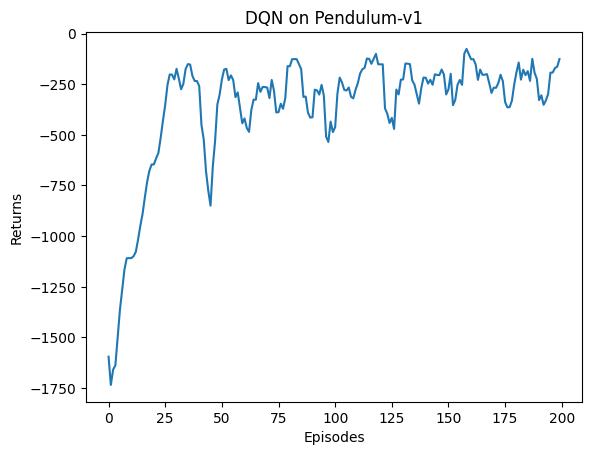

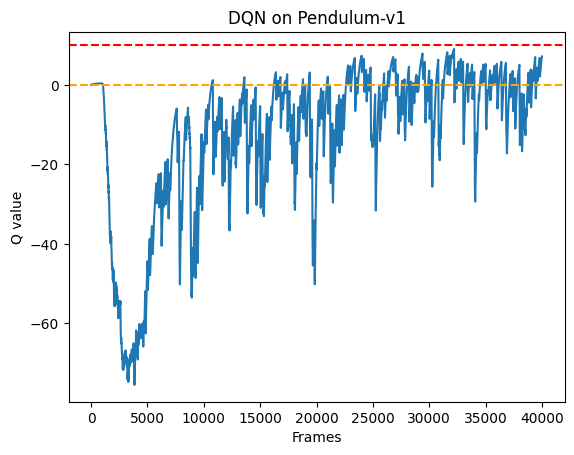

In [7]:
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon,
            target_update, device)
return_list, max_q_value_list = train_DQN(agent, env, num_episodes,
                                          replay_buffer, minimal_size,
                                          batch_size)

episodes_list = list(range(len(return_list)))
mv_return = rl_utils.moving_average(return_list, 5)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

frames_list = list(range(len(max_q_value_list)))
plt.plot(frames_list, max_q_value_list)
plt.axhline(0, c='orange', ls='--')
plt.axhline(10, c='red', ls='--')
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title('DQN on {}'.format(env_name))
plt.show()

DQN 算法在倒立摆环境中能取得不错的回报，最后的期望回报在-200 左右，但是不少 Q 值超过了 0，有一些还超过了 10，该现象便是 DQN 算法中的 Q 值过高估计

然后来看一下 double DQN

/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(
Iteration 9: 100%|██████████| 20/20 [00:06<00:00,  3.28it/s, episode=200, return=-205.816]


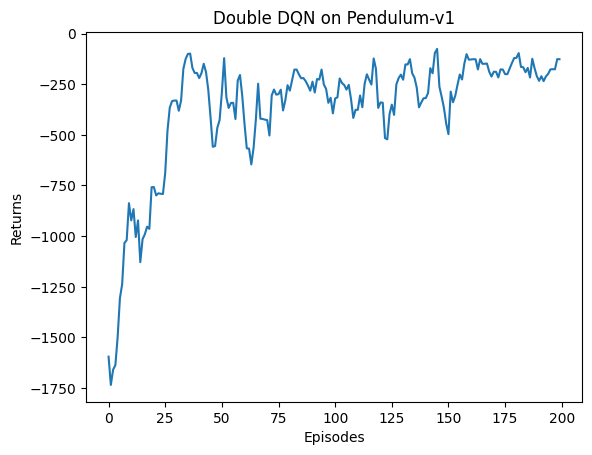

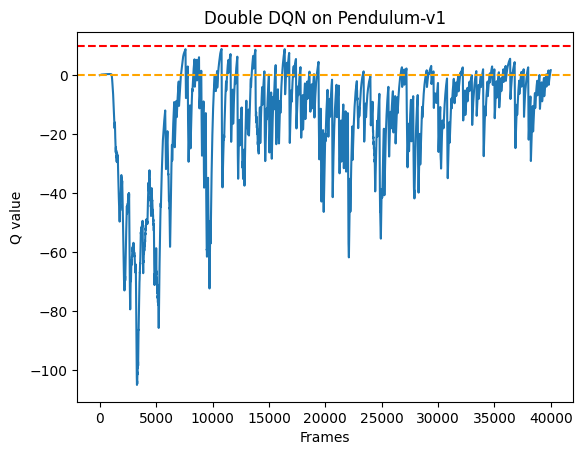

In [8]:
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon,
            target_update, device, 'DoubleDQN')
return_list, max_q_value_list = train_DQN(agent, env, num_episodes,
                                          replay_buffer, minimal_size,
                                          batch_size)

episodes_list = list(range(len(return_list)))
mv_return = rl_utils.moving_average(return_list, 5)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Double DQN on {}'.format(env_name))
plt.show()

frames_list = list(range(len(max_q_value_list)))
plt.plot(frames_list, max_q_value_list)
plt.axhline(0, c='orange', ls='--')
plt.axhline(10, c='red', ls='--')
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title('Double DQN on {}'.format(env_name))
plt.show()

与普通的 DQN 相比，Double DQN 比较少出现值大于 0 的情况，说明 Q 值过高估计的问题得到了很大缓解

Dueling DQN代码实践，详细讲解看飞书

Dueling DQN 与 DQN 相比的差异只是在网络结构上，大部分代码依然可以继续沿用。我们定义状态价值函数和优势函数的复合神经网络VAnet

In [10]:
class VAnet(torch.nn.Module):
    """
        只有一层隐藏层的A网络和V网络
    """
    def __init__(self, state_dim, hidden_dim, action_dim):
        """
            初始化
            state_dim：输入层维度
            hidden_dim：隐藏层维度
            action_dim：输出层维度
        """
        super(VAnet, self).__init__()

        # 共享网络部分，这是一个全连接层，负责从原始状态输入中提取特征。它是 A 网络和 V 网络 共享 的底层结构
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)  
        # 优势流，接收共享层的输出，最终输出维度为 action_dim 的张量，计算出当前状态下，每个动作的优势值 A
        self.fc_A = torch.nn.Linear(hidden_dim, action_dim)
        # 价值流，接收共享层的输出，最终输出维度为 1 的标量。即计算出当前这个状态的总价值 $V$
        self.fc_V = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
            前向传播
            x：输入层特征
        """
        A = self.fc_A(F.relu(self.fc1(x)))
        V = self.fc_V(F.relu(self.fc1(x)))
        Q = V + A - A.mean(1).view(-1, 1)  # Q值由V值和A值计算得到
        return Q
    
class DQN:
    """
        DQN算法,包括Double DQN和Dueling DQN 
    """
    def __init__(self, state_dim, hidden_dim, action_dim, learning_rate, gamma, epsilon, target_update, device, dqn_type='VanillaDQN'):
        """
            初始化
            state_dim：输入层维度（状态空间的维度）
            hidden_dim：隐藏层维度
            action_dim：输出层维度
            learning_rate：学习率
            gamma：折扣因子
            epsilon：epsilon-贪婪策略中的探索概率
            target_update：目标网络更新的频率（经过多少步更新一次）
            device：计算运行的设备
            dqn_type：算法类型，默认是普通DQN
        """
        self.action_dim = action_dim

        # Dueling DQN采取不一样的网络框架
        if dqn_type == 'DuelingDQN':  
            self.q_net = VAnet(state_dim, hidden_dim,
                               self.action_dim).to(device)
            self.target_q_net = VAnet(state_dim, hidden_dim,
                                      self.action_dim).to(device)
        else:
            self.q_net = Qnet(state_dim, hidden_dim,
                              self.action_dim).to(device)
            self.target_q_net = Qnet(state_dim, hidden_dim,
                                     self.action_dim).to(device)
        
        self.optimizer = torch.optim.Adam(self.q_net.parameters(),lr=learning_rate)
        self.gamma = gamma
        self.epsilon = epsilon
        self.target_update = target_update
        self.count = 0
        self.dqn_type = dqn_type
        self.device = device

    def take_action(self, state):
        """
            epsilon-贪婪策略采取动作
            state：
        """
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else:
            state = torch.tensor([state], dtype=torch.float).to(self.device)
            action = self.q_net(state).argmax().item()
        return action
    
    def max_q_value(self, state):
        """
            这是一个辅助函数，用于在训练过程中记录和监控最大 Q 值
            state：
        """
        # 输入状态，返回当前网络评估出的最大 Q 值
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        return self.q_net(state).max().item()
    
    def update(self, transition_dict):
        """
            策略更新
            transition_dict：从经验回放池取出的一个批次（Batch）的数据字典
        """
        # 将采样到的各种数据转化为 PyTorch 张量，并调整形状（view），送入设备。
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

        # 用当前网络计算 states 的所有 Q 值，然后用 gather 函数提取出实际执行的 actions 对应的 Q 值（即模型当前的预测值）
        q_values = self.q_net(states).gather(1, actions)
    
        # 如果是 Double DQN 算法：
        if self.dqn_type == 'DoubleDQN':
            # 第一步：用【当前网络】选出下一个状态中 Q 值最大的那个动作的索引。
            max_action = self.q_net(next_states).max(1)[1].view(-1, 1)
            # 第二步：用【目标网络】去评估刚才选出的那个动作的 Q 值。这就是解耦了“动作选择”和“价值评估”，防止盲目高估。
            max_next_q_values = self.target_q_net(next_states).gather(1, max_action)
        # 如果是 Vanilla DQN 或仅仅是 Dueling DQN：
        else:
            # 直接用【目标网络】选出下一个状态最大的 Q 值。
            max_next_q_values = self.target_q_net(next_states).max(1)[0].view(-1, 1)
        
        # 使用贝尔曼方程计算时序差分目标（TD Target）。如果当前步是结束步（dones=1），则没有未来奖励，直接等于当前 rewards
        q_targets = rewards + self.gamma * max_next_q_values * (1 - dones)

        # 计算预测 Q 值和目标 Q 值之间的均方误差损失（MSE Loss）
        dqn_loss = torch.mean(F.mse_loss(q_values, q_targets))

        # 清空优化器中上一步残留的梯度。
        self.optimizer.zero_grad() 

        # 根据损失进行反向传播，计算梯度。
        dqn_loss.backward() 
        
        # 优化器根据梯度更新当前网络 q_net 的参数。
        self.optimizer.step() 
        
        # 检查计数器，如果达到了设定的同步频率 target_update：
        if self.count % self.target_update == 0:
            # 将当前网络 q_net 的参数完全复制（硬更新）给目标网络 target_q_net。
            self.target_q_net.load_state_dict(self.q_net.state_dict())
        
        # 计数器加一。
        self.count += 1
        

主训练流程与结果可视化

/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(
Iteration 9: 100%|██████████| 20/20 [00:09<00:00,  2.03it/s, episode=200, return=-185.055]


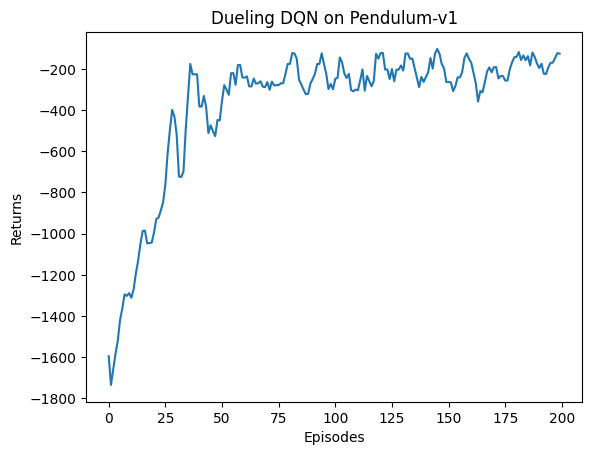

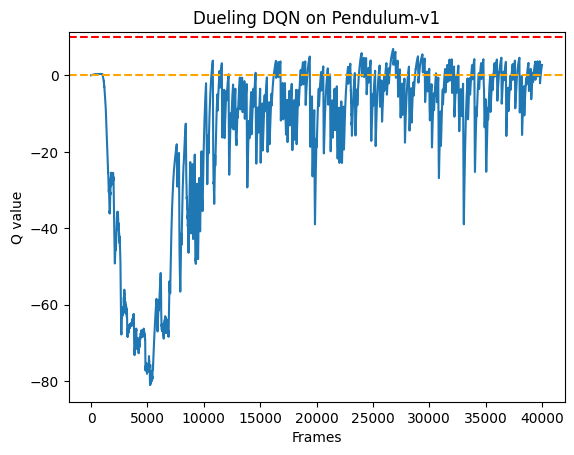

In [11]:
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
# 固定 Python、NumPy、Gym 环境和 PyTorch 的随机种子。保证每次运行代码，随机初始化的状态和探索过程是一样的，方便复现结果和对比算法。

replay_buffer = rl_utils.ReplayBuffer(buffer_size)
# 实例化一个经验回放池，用于打乱数据相关性，提高数据利用率。

agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon, target_update, device, 'DuelingDQN')
# 实例化我们写好的 DQN 智能体，并且明确指定 dqn_type 为 'DuelingDQN'。

return_list, max_q_value_list = train_DQN(agent, env, num_episodes, replay_buffer, minimal_size, batch_size)
# 调用外部定义的训练函数，传入智能体、环境、超参数等进行训练。训练结束后返回每个 Episode 的总回报列表，以及最大 Q 值变化列表。

# --- 下面是第一张图：绘制回报曲线 ---
episodes_list = list(range(len(return_list)))
# 生成 X 轴数据（0 到 num_episodes）。
mv_return = rl_utils.moving_average(return_list, 5)
# 使用移动平均平滑数据。因为强化学习的单次回报震荡很大，平滑后更容易看出模型能力的上升趋势。
plt.plot(episodes_list, mv_return) 
# 画线。
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Dueling DQN on {}'.format(env_name))
plt.show()

# --- 下面是第二张图：绘制最大 Q 值曲线 ---
frames_list = list(range(len(max_q_value_list)))
# 生成 X 轴数据（按帧数/步数统计）。
plt.plot(frames_list, max_q_value_list)
# 画出最大 Q 值随时间的变化曲线。
plt.axhline(0, c='orange', ls='--')
# 画一条 y=0 的橙色虚线作为参考。
plt.axhline(10, c='red', ls='--')
# 画一条 y=10 的红色虚线作为参考（通常代表该环境下的完美 Q 值或某个基准值）。
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title('Dueling DQN on {}'.format(env_name))
plt.show()